In [1]:
import os

import numpy as np
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

import torch
import torchvision
from torchvision.transforms import transforms

from PIL import Image

from preprocessing_module import find_class_names_filenames, stratified_split_data_paths, NatureCityScenesDataset

In [2]:
import os
import sys
import random
from pathlib import Path
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset

from sklearn.model_selection import train_test_split


# ---- Project paths ----
PROJECT_ROOT = Path("quadrant_dots_project").resolve()
DATA_ROOT = PROJECT_ROOT / ".." / ".." / "Datasets" / "quadrant_dots_rgb"

# Make project importable (so we can import our dataset + generator modules)
sys.path.append(str(PROJECT_ROOT))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    
set_seed(42)


Device: cpu


In [3]:
from sklearn.metrics import average_precision_score

In [12]:
DATASET_PATH = r"./mandatory1_data"

class_names, class_filenames = find_class_names_filenames(DATASET_PATH)
x_train_paths, x_val_paths, x_test_paths, y_train, y_val, y_test = stratified_split_data_paths(DATASET_PATH, class_names, class_filenames)

transform = transforms.Compose([
    transforms.Resize((224, 224)), # AlexNet standard size: 224x224
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# transform = transforms.Compose([
#     transforms.Resize((150, 150)),
#     transforms.ToTensor(),
#     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
# ])

# transform = transforms.Compose([
#     transforms.ToTensor(),
#     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
# ])

train_set = NatureCityScenesDataset(x_train_paths, y_train, transform=transform)
val_set = NatureCityScenesDataset(x_val_paths, y_val, transform=transform)
test_set = NatureCityScenesDataset(x_test_paths, y_test, transform=transform)

BATCH_SIZE = 32
train_loader = torch.utils.data.DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = torch.utils.data.DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)

subset_indices = list(range(60))
train_subset = torch.utils.data.Subset(train_set, subset_indices)
val_subset = torch.utils.data.Subset(val_set, subset_indices)
test_subset = torch.utils.data.Subset(test_set, subset_indices)

train_loader = torch.utils.data.DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = torch.utils.data.DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
test_loader = torch.utils.data.DataLoader(test_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)

In [13]:
from dataclasses import dataclass
from typing import Callable, Dict, Optional, Tuple

@dataclass
class EpochStats:
    loss: float
    acc: float
    mAP: float
    AP_per_class: float


class Trainer:
    def __init__(
        self,
        model: nn.Module,
        criterion: nn.Module,
        optimizer: torch.optim.Optimizer,
        device: torch.device,
        augment_fn: Optional[Callable[[torch.Tensor], torch.Tensor]] = None,
    ):
        self.model = model
        self.criterion = criterion
        self.optimizer = optimizer
        self.device = device
        self.augment_fn = augment_fn

        self.history: Dict[str, list] = {
            "train_loss": [],
            "train_acc": [],
            "val_loss": [],
            "val_acc": [],
            "val_mAP": [],
            "val_AP_per_class": [],
        }

    @staticmethod
    def _accuracy(logits: torch.Tensor, targets: torch.Tensor) -> float:
        preds = logits.argmax(dim=1)
        return (preds == targets).float().mean().item()

    def train_one_epoch(self, loader: DataLoader) -> EpochStats:
        self.model.train()

        total_loss = 0.0
        total_acc = 0.0
        n_batches = 0

        for images, targets in loader:
            images = images.to(self.device, non_blocking=True)
            targets = targets.to(self.device, non_blocking=True)

            # Apply augmentation policy only during training (optional)
            if self.augment_fn is not None:
                images = self.augment_fn(images)

            logits = self.model(images)
            loss = self.criterion(logits, targets)

            self.optimizer.zero_grad(set_to_none=True)
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item()
            total_acc += self._accuracy(logits, targets)
            n_batches += 1

        return EpochStats(loss=total_loss / n_batches, acc=total_acc / n_batches, mAP=0.0, AP_per_class=0.0)

    @torch.no_grad()
    def evaluate(self, loader: DataLoader) -> EpochStats:
        self.model.eval()

        total_loss = 0.0
        total_acc = 0.0
        n_batches = 0

        store_logits = []
        store_targets = []

        for images, targets in loader:
            images = images.to(self.device, non_blocking=True)
            targets = targets.to(self.device, non_blocking=True)

            logits = self.model(images)
            loss = self.criterion(logits, targets)

            total_loss += loss.item()
            total_acc += self._accuracy(logits, targets)
            n_batches += 1

            store_logits.append(logits)
            store_targets.append(targets)

        # logits have shape [batch size, number of classes], 
        # first row is the raw output from the model for the first individual sample of the batch.
        # Turn list of tensors (one for each batch) into one tensor-typed list
        store_logits = torch.concatenate(store_logits)
        store_targets = torch.concatenate(store_targets)

        # Turn raw model output into probabilities with softmax, dim=1 so we get sofmax per indv. sample over all classes
        prob_scores = torch.softmax(store_logits, dim=1)#.cpu().numpy() or detach().cpu().numpy()

        # Turn target values (class number) into one-hot encoded tensor 
        n_classes = store_logits.shape[1]
        one_hot_targets = torch.nn.functional.one_hot(store_targets, num_classes=n_classes)#.cpu().numpy() or detach().cpu().numpy()

        
        mean_avg_precision = average_precision_score(y_score=prob_scores, y_true=one_hot_targets)
        avg_precision_per_class = average_precision_score(y_score=prob_scores, y_true=one_hot_targets, average=None)

        return EpochStats(loss=total_loss/n_batches, acc=total_acc/n_batches, mAP=mean_avg_precision, AP_per_class=avg_precision_per_class)

    def fit(self, train_loader: DataLoader, val_loader: DataLoader, epochs: int = 10):
        for epoch in range(1, epochs + 1):
            train_stats = self.train_one_epoch(train_loader)
            val_stats = self.evaluate(val_loader)

            self.history["train_loss"].append(train_stats.loss)
            self.history["train_acc"].append(train_stats.acc)
            self.history["val_loss"].append(val_stats.loss)
            self.history["val_acc"].append(val_stats.acc)
            self.history["val_mAP"].append(val_stats.mAP)
            self.history["val_AP_per_class"].append(val_stats.AP_per_class)

            print(
                f"Epoch {epoch:02d} | "
                f"train loss: {train_stats.loss:.4f}, acc: {train_stats.acc:.3f} | "
                f"val loss: {val_stats.loss:.4f}, acc: {val_stats.acc:.3f}, mean average precision (mAP): {val_stats.mAP}, AP per class: {val_stats.AP_per_class}"
            )


In [14]:
def batch_noise_augment(images: torch.Tensor, std: float = 0.03) -> torch.Tensor:
    noise = torch.randn_like(images) * std
    return torch.clamp(images + noise, 0.0, 1.0)

from ResNet import ResNet

model_ResNet18 = ResNet(img_channels=3, num_layers=18, num_classes=6).to(device)

num_epochs = 4

In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_ResNet18.parameters(), lr=1e-3)

trainer_ResNet18_1 = Trainer(
    model=model_ResNet18,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    augment_fn=lambda x: batch_noise_augment(x, std=0.02),
)

trainer_ResNet18_1.fit(train_loader, val_loader, epochs=num_epochs)

Epoch 01 | train loss: 2.4912, acc: 0.241 | val loss: 1.7645, acc: 0.232, mean average precision (mAP): 0.37404795904821997, AP per class: [0.32503405 0.73341658 0.36193859 0.29296473 0.36182865 0.16910515]
Epoch 02 | train loss: 2.4231, acc: 0.312 | val loss: 2.0059, acc: 0.217, mean average precision (mAP): 0.27504003563582313, AP per class: [0.17736282 0.4267113  0.48465076 0.10541941 0.23285566 0.22324026]
Epoch 03 | train loss: 1.7796, acc: 0.346 | val loss: 13.3106, acc: 0.219, mean average precision (mAP): 0.226461802190848, AP per class: [0.14579584 0.10878096 0.5479782  0.11307951 0.21147768 0.23165862]
Epoch 04 | train loss: 1.4943, acc: 0.411 | val loss: 23.0291, acc: 0.234, mean average precision (mAP): 0.21809109476582142, AP per class: [0.15018124 0.08659321 0.52194301 0.10861399 0.19720519 0.24400992]


In [16]:
trainer_ResNet18_1.evaluate(test_loader)

EpochStats(loss=22.477275848388672, acc=0.2522321492433548, mAP=0.2669058142897986, AP_per_class=array([0.25108705, 0.31130635, 0.16709752, 0.18613487, 0.38251063,
       0.30329847]))

In [17]:
trainer_ResNet18_1.history

{'train_loss': [2.4912092685699463,
  2.4231035709381104,
  1.779620885848999,
  1.494276523590088],
 'train_acc': [0.2410714328289032,
  0.3125,
  0.3459821492433548,
  0.4107142835855484],
 'val_loss': [1.7644551396369934,
  2.005926012992859,
  13.310564994812012,
  23.02906608581543],
 'val_acc': [0.2321428582072258, 0.2165178582072258, 0.21875, 0.234375],
 'val_mAP': [0.37404795904821997,
  0.27504003563582313,
  0.226461802190848,
  0.21809109476582142],
 'val_AP_per_class': [array([0.32503405, 0.73341658, 0.36193859, 0.29296473, 0.36182865,
         0.16910515]),
  array([0.17736282, 0.4267113 , 0.48465076, 0.10541941, 0.23285566,
         0.22324026]),
  array([0.14579584, 0.10878096, 0.5479782 , 0.11307951, 0.21147768,
         0.23165862]),
  array([0.15018124, 0.08659321, 0.52194301, 0.10861399, 0.19720519,
         0.24400992])]}

In [23]:
trainer_ResNet18_1.history["val_mAP"]

[0.37404795904821997,
 0.27504003563582313,
 0.226461802190848,
 0.21809109476582142]

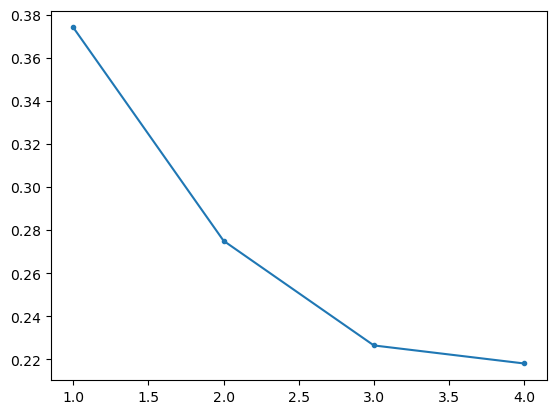

In [24]:
values_mAP = trainer_ResNet18_1.history["val_mAP"]
plt.plot(range(1, len(values_mAP) + 1), trainer_ResNet18_1.history["val_mAP"], '.-')

In [25]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_ResNet18.parameters(), lr=1e-2)

trainer_ResNet18_2 = Trainer(
    model=model_ResNet18,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    augment_fn=lambda x: batch_noise_augment(x, std=0.02),
)

trainer_ResNet18_2.fit(train_loader, val_loader, epochs=num_epochs)

Epoch 01 | train loss: 3.1307, acc: 0.246 | val loss: 29554409.0000, acc: 0.103, mean average precision (mAP): 0.16666666666666666, AP per class: [0.16666667 0.11666667 0.21666667 0.1        0.2        0.2       ]
Epoch 02 | train loss: 2.6794, acc: 0.183 | val loss: 3063001.1250, acc: 0.098, mean average precision (mAP): 0.16666666666666666, AP per class: [0.16666667 0.11666667 0.21666667 0.1        0.2        0.2       ]
Epoch 03 | train loss: 2.0795, acc: 0.283 | val loss: 34595.6660, acc: 0.100, mean average precision (mAP): 0.16666666666666666, AP per class: [0.16666667 0.11666667 0.21666667 0.1        0.2        0.2       ]
Epoch 04 | train loss: 1.6900, acc: 0.375 | val loss: 7064.1702, acc: 0.100, mean average precision (mAP): 0.16666666666666666, AP per class: [0.16666667 0.11666667 0.21666667 0.1        0.2        0.2       ]


In [26]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.RMSprop(model_ResNet18.parameters(), lr=0.03)

trainer_ResNet18_3 = Trainer(
    model=model_ResNet18,
    criterion=criterion,
    optimizer=optimizer,
    device=device,
    augment_fn=lambda x: batch_noise_augment(x, std=0.02),
)

trainer_ResNet18_3.fit(train_loader, val_loader, epochs=num_epochs)

Epoch 01 | train loss: 60.6041, acc: 0.163 | val loss: 80431332861149184.0000, acc: 0.219, mean average precision (mAP): 0.16666666666666666, AP per class: [0.16666667 0.11666667 0.21666667 0.1        0.2        0.2       ]
Epoch 02 | train loss: 6.7556, acc: 0.203 | val loss: 67766646.0000, acc: 0.165, mean average precision (mAP): 0.16666666666666666, AP per class: [0.16666667 0.11666667 0.21666667 0.1        0.2        0.2       ]
Epoch 03 | train loss: 3.4104, acc: 0.248 | val loss: 1842559.1875, acc: 0.203, mean average precision (mAP): 0.16666666666666666, AP per class: [0.16666667 0.11666667 0.21666667 0.1        0.2        0.2       ]
Epoch 04 | train loss: 8.6387, acc: 0.261 | val loss: 5840.0405, acc: 0.165, mean average precision (mAP): 0.16666666666666666, AP per class: [0.16666667 0.11666667 0.21666667 0.1        0.2        0.2       ]


In [27]:
stored_imgs_list = []
stored_labels_list = []
for i, j in train_loader:
    stored_imgs_list.append(i)
    stored_labels_list.append(j)
    

In [28]:
stored_labels_list

[tensor([2, 2, 5, 5, 1, 2, 0, 4, 3, 0, 1, 1, 0, 5, 1, 2, 4, 3, 3, 3, 3, 0, 5, 0,
         1, 3, 0, 3, 2, 3, 4, 0]),
 tensor([3, 0, 0, 0, 3, 5, 1, 3, 0, 4, 2, 4, 4, 0, 1, 4, 4, 1, 1, 5, 1, 3, 5, 5,
         3, 1, 1, 3])]

In [29]:
torch.concatenate(stored_labels_list, dim=0)

tensor([2, 2, 5, 5, 1, 2, 0, 4, 3, 0, 1, 1, 0, 5, 1, 2, 4, 3, 3, 3, 3, 0, 5, 0,
        1, 3, 0, 3, 2, 3, 4, 0, 3, 0, 0, 0, 3, 5, 1, 3, 0, 4, 2, 4, 4, 0, 1, 4,
        4, 1, 1, 5, 1, 3, 5, 5, 3, 1, 1, 3])

In [ ]:
torch.nn.functional.one_hot(torch.concatenate(stored_labels_list, dim=0))

In [31]:
average_precision_score(y_score=[0.25, 0.6, 0.15], y_true=[0, 0, 1])

0.3333333333333333

In [32]:
torch.sum(torch.softmax(torch.tensor(
    [[2.4105, -1.2031,  0.5422, -3.1102,  4.2019, -0.8921], [6.4105, -0.2031,  0.6422, -3.1102,  4.2019, -0.8921]]
    ), dim=1), dim=1)

tensor([1., 1.])